Executive analytical datasets loaded.


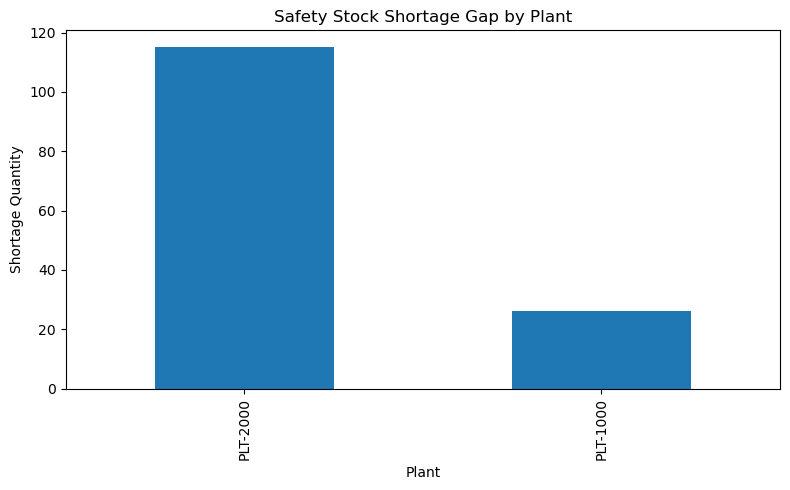

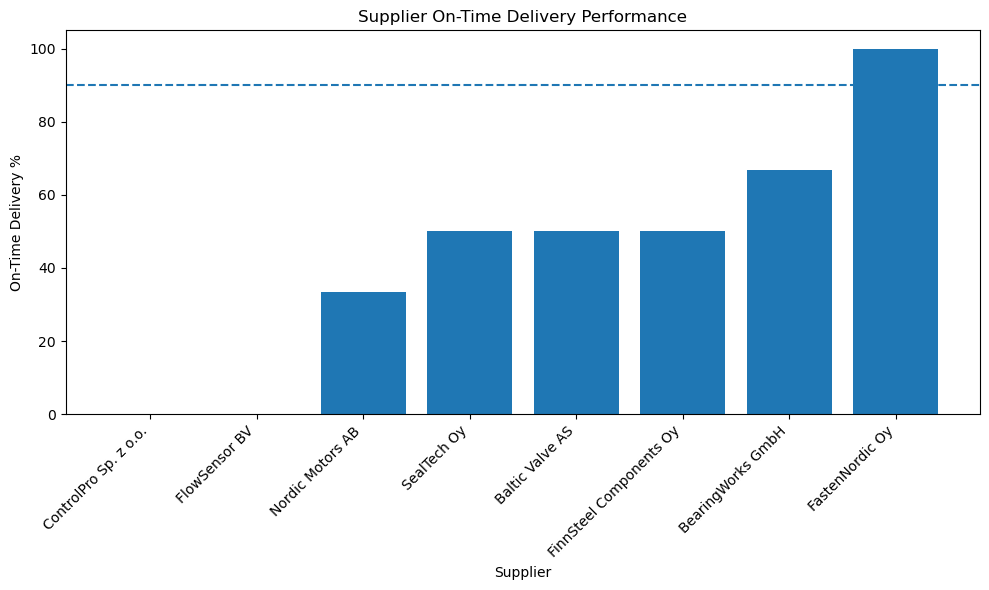

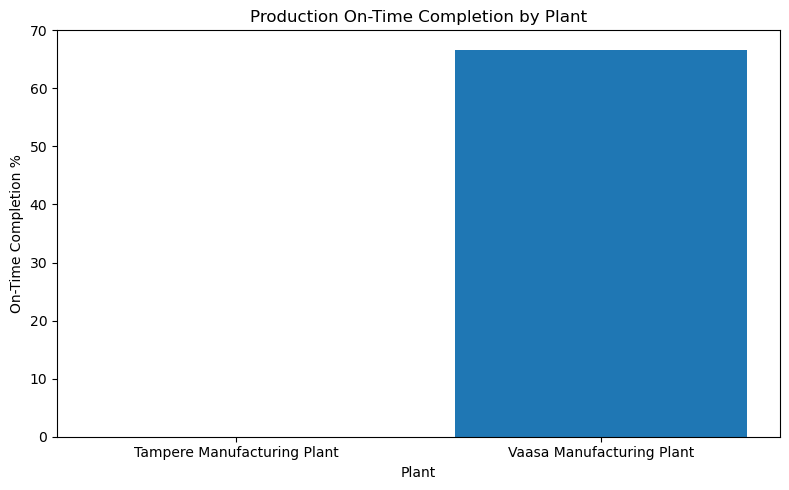

Executive analytics exported successfully.


In [8]:
# -------------------------------------------------
# STEP 1 — Import libraries
# -------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# -------------------------------------------------
# STEP 2 — Define project paths
# -------------------------------------------------

output_path = Path("../outputs")

chart_path = output_path / "charts"

chart_path.mkdir(
    parents=True,
    exist_ok=True
)


# -------------------------------------------------
# STEP 3 — Load analytical outputs
# -------------------------------------------------

kpi_summary = pd.read_csv(
    output_path / "kpi_summary.csv"
)

inventory_risk = pd.read_csv(
    output_path / "inventory_risk.csv"
)

safety_stock_shortages = pd.read_csv(
    output_path / "safety_stock_shortages.csv"
)

c_class_overstock = pd.read_csv(
    output_path / "c_class_overstock.csv"
)

interplant_transfer = pd.read_csv(
    output_path / "interplant_transfer_opportunities.csv"
)

supplier_scorecard = pd.read_csv(
    output_path / "supplier_scorecard.csv"
)

production_kpis = pd.read_csv(
    output_path / "production_kpis.csv"
)

plant_performance = pd.read_csv(
    output_path / "plant_production_performance.csv"
)

print("Executive analytical datasets loaded.")

# -------------------------------------------------
# STEP 4 — Build executive KPI summary
# -------------------------------------------------

# Helper function to retrieve KPI values
def get_kpi(df, kpi_name):
    return df.loc[
        df["KPI"] == kpi_name,
        "Value"
    ].iloc[0]


latest_inventory_value = get_kpi(
    kpi_summary,
    "Latest Inventory Value EUR"
)

supplier_otd = get_kpi(
    kpi_summary,
    "Supplier On-Time Delivery %"
)

production_otd = get_kpi(
    kpi_summary,
    "Production On-Time Completion %"
)

shortage_orders = get_kpi(
    kpi_summary,
    "Shortage-Affected Orders"
)


executive_kpis = pd.DataFrame({
    "KPI": [
        "Latest Inventory Value EUR",
        "Supplier On-Time Delivery %",
        "Production On-Time %",
        "Shortage-Affected Orders",
        "Safety Stock Shortage Positions",
        "Interplant Transfer Opportunities",
        "High-Risk Suppliers"
    ],
    "Value": [
        latest_inventory_value,
        supplier_otd,
        production_otd,
        shortage_orders,
        len(safety_stock_shortages),
        len(interplant_transfer),
        (
            supplier_scorecard["Review_Priority"]
            == "High Review Priority"
        ).sum()
    ]
})

executive_kpis

# -------------------------------------------------
# STEP 5 — Build cross-functional risk summary
# -------------------------------------------------

risk_summary = pd.DataFrame({
    "Risk_Area": [
        "Inventory Availability",
        "Supplier Delivery",
        "Supplier Quality",
        "Production Reliability",
        "Working Capital",
        "Stock Allocation"
    ],

    "Evidence": [
        f"{len(safety_stock_shortages)} material-plant positions below safety stock",

        f"Overall supplier OTD is {supplier_otd:.1f}%",

        "Quality rejections exist on purchased materials",

        f"Production on-time completion is {production_otd:.1f}%",

        f"{len(c_class_overstock)} C-class overstock positions identified",

        f"{len(interplant_transfer)} potential interplant transfers identified"
    ],

    "Management_Action": [
        "Prioritise critical shortages and review planning parameters",

        "Launch supplier performance corrective actions",

        "Strengthen supplier quality monitoring",

        "Investigate production delays and shortage dependencies",

        "Reduce low-priority excess inventory",

        "Use internal stock balancing before new purchasing"
    ]
})

risk_summary

# -------------------------------------------------
# STEP 6 — Visualise inventory shortage exposure
# -------------------------------------------------

shortage_chart = (
    safety_stock_shortages
    .groupby("Plant_ID")["Safety_Stock_Gap"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

shortage_chart.plot(
    kind="bar"
)

plt.title(
    "Safety Stock Shortage Gap by Plant"
)

plt.xlabel(
    "Plant"
)

plt.ylabel(
    "Shortage Quantity"
)

plt.tight_layout()

plt.savefig(
    chart_path / "safety_stock_shortage_by_plant.png"
)

plt.show()

# -------------------------------------------------
# STEP 7 — Visualise supplier delivery performance
# -------------------------------------------------

supplier_chart = supplier_scorecard.sort_values(
    "On_Time_Delivery_Pct"
)

plt.figure(figsize=(10, 6))

plt.bar(
    supplier_chart["Supplier_Name"],
    supplier_chart["On_Time_Delivery_Pct"]
)

plt.axhline(
    90,
    linestyle="--"
)

plt.title(
    "Supplier On-Time Delivery Performance"
)

plt.xlabel(
    "Supplier"
)

plt.ylabel(
    "On-Time Delivery %"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    chart_path / "supplier_otd_performance.png"
)

plt.show()

# -------------------------------------------------
# STEP 8 — Compare production performance by plant
# -------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    plant_performance["Plant_Name"],
    plant_performance["Production_On_Time_Pct"]
)

plt.title(
    "Production On-Time Completion by Plant"
)

plt.xlabel(
    "Plant"
)

plt.ylabel(
    "On-Time Completion %"
)

plt.tight_layout()

plt.savefig(
    chart_path / "production_on_time_by_plant.png"
)

plt.show()

# -------------------------------------------------
# STEP 9 — Build consultant recommendation register
# -------------------------------------------------

consultant_recommendations = pd.DataFrame({
    "Priority": [
        "Critical",
        "Critical",
        "High",
        "High",
        "High",
        "Medium"
    ],

    "Recommendation": [
        "Correct unrealistic material planning lead times",

        "Introduce interplant transfer review before external purchasing",

        "Launch supplier delivery corrective-action programme",

        "Reduce excess C-class inventory",

        "Improve supplier quality controls",

        "Create integrated ERP performance dashboard"
    ],

    "Business_Reason": [
        "Actual purchasing lead times exceed master-data assumptions for several materials",

        "Shortages exist while usable stock is available at other plants",

        "Supplier OTD performance is significantly below target",

        "Low-priority inventory ties up working capital",

        "Rejected material reduces real usable inventory",

        "Inventory, procurement and production risks are currently analysed separately"
    ],

    "Expected_Impact": [
        "More reliable MRP and fewer shortages",

        "Lower emergency purchasing and better stock utilisation",

        "Improved material availability",

        "Working-capital reduction",

        "Higher usable receipt quantity",

        "Faster cross-functional management decisions"
    ]
})

consultant_recommendations

# -------------------------------------------------
# STEP 10 — Export executive analytical outputs
# -------------------------------------------------

executive_kpis.to_csv(
    output_path / "executive_kpis.csv",
    index=False
)

risk_summary.to_csv(
    output_path / "executive_risk_summary.csv",
    index=False
)

consultant_recommendations.to_csv(
    output_path / "consultant_recommendations.csv",
    index=False
)

print("Executive analytics exported successfully.")